In [166]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Grafiklerin notebook içinde görünmesi için
%matplotlib inline

In [167]:
df = pd.read_csv("data/europe_air_routes.csv")

In [168]:
#EDA(Exploratory Data Analysis)- Veri Keşfi
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 18111 entries, 0 to 18110
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            18111 non-null  int64  
 1   iata_from                     18111 non-null  str    
 2   iata_to                       18111 non-null  str    
 3   price                         18111 non-null  int64  
 4   day1                          18111 non-null  str    
 5   day2                          18111 non-null  str    
 6   day3                          18111 non-null  str    
 7   day4                          18111 non-null  str    
 8   day5                          18111 non-null  str    
 9   day6                          18111 non-null  str    
 10  day7                          18111 non-null  str    
 11  flights_per_day               18111 non-null  str    
 12  common_duration               18111 non-null  int64  
 13  flights_per_

Index(['id', 'iata_from', 'iata_to', 'price', 'day1', 'day2', 'day3', 'day4',
       'day5', 'day6', 'day7', 'flights_per_day', 'common_duration',
       'flights_per_week', 'first_flight', 'last_flight', 'airlineroutes',
       'arrival_airport_country_code', 'arrival_airport_name',
       'arrival_airport_city_name', 'arrival_airport_city_name_en',
       'arrival_airport_country', 'arrival_airport_no_routes',
       'departure_city', 'departure_country', 'departure_ICAO',
       'departure_latitude', 'departure_longitude', 'departure_altitude',
       'arrival_ICAO', 'arrival_latitude', 'arrival_longitude',
       'arrival_altitude'],
      dtype='str')

In [169]:
#EDA - Veri Keşfi
print(f"Satır Sayısı: {df.shape[0]}")
print(f"Sütun Sayısı: {df.shape[1]}")


Satır Sayısı: 18111
Sütun Sayısı: 33


In [170]:
#İlk 5 satır
df.head()

,id,iata_from,iata_to,price,day1,day2,day3,day4,day5,day6,...,departure_city,departure_country,departure_ICAO,departure_latitude,departure_longitude,departure_altitude,arrival_ICAO,arrival_latitude,arrival_longitude,arrival_altitude
0,46316,TZL,DTM,70,no,yes,no,yes,no,yes,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDLW,51.518299,7.612240,425.0
1,46319,TZL,FMM,30,yes,upcoming,upcoming,yes,yes,upcoming,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDJA,47.988800,10.239500,2077.0
2,46322,TZL,MLH,40,no,yes,no,yes,no,yes,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,LFSB,47.590000,7.529167,885.0
3,77197,TZL,BER,40,upcoming,no,upcoming,no,upcoming,no,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,EDDB,52.380001,13.522500,157.0
4,46323,TZL,MMX,90,no,upcoming,no,upcoming,no,upcoming,...,Tulza,Bosnia and Herzegovina,LQTZ,44.458698,18.7248,784,ESMS,55.536305,13.376198,236.0


In [171]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

arrival_ICAO                    94
arrival_latitude                94
arrival_longitude               94
arrival_altitude                94
arrival_airport_country_code     3
dtype: int64

Veri setindeki eksik değer oranı %1'in altındadır ve sosyal ağın oluşturulmasında kullanılan IATA kodları (iata_from, iata_to) eksiksiz olduğundan analiz sonuçlarını etkilememektedir.

In [172]:
df.describe()

,id,price,common_duration,flights_per_week,arrival_airport_no_routes,departure_latitude,departure_longitude,departure_altitude,arrival_latitude,arrival_longitude,arrival_altitude
count,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18111.000000,18017.000000,18017.000000,18017.000000
mean,40968.389818,131.500193,188.270554,8.935343,102.961846,46.527647,10.626848,422.184584,43.509688,11.135838,477.822889
std,28947.003864,316.923778,132.300212,14.501401,71.253309,7.323643,13.545896,520.332995,11.331455,28.655810,745.766790
min,14.000000,0.000000,20.000000,0.000000,1.000000,27.931900,-25.697901,-15.000000,-34.838402,-149.996002,-72.000000
25%,16213.000000,30.000000,110.000000,2.000000,46.000000,41.138901,0.695556,80.000000,38.282200,-0.461941,65.000000
50%,34771.000000,70.000000,150.000000,4.000000,91.000000,46.927700,9.221960,257.000000,44.413300,10.227200,242.000000
75%,66474.000000,150.000000,220.000000,10.000000,149.000000,51.841301,19.261093,506.000000,51.148102,21.425600,527.000000
max,96475.000000,16100.000000,1120.000000,189.000000,316.000000,69.683296,77.040497,3125.000000,78.246101,177.740997,8361.000000


In [173]:
airports = set(df["iata_from"]).union(set(df["iata_to"]))

print(f"Toplam Havalimanı Sayısı: {len(airports)}")

Toplam Havalimanı Sayısı: 983


In [174]:
##Toplam rota sayısı
print("Toplam rota :" , len(df))

Toplam rota : 18111


In [175]:
##En çok kalkış yapılan havalimanları
top_departure_airports = df["iata_from"].value_counts().head(10)
print("En çok kalkış yapılan havalimanları:")
print(top_departure_airports)

En çok kalkış yapılan havalimanları:
iata_from
IST    316
FRA    285
CDG    277
AMS    267
FCO    235
MUC    229
MAD    226
BCN    224
LHR    217
ZRH    211
Name: count, dtype: int64


In [176]:
##En çok varış yapılan havalimanları
top_arrival_airports = df["iata_to"].value_counts().head(10)

In [177]:
##En yoğun şehirler
top_cities_arv = df["arrival_airport_city_name"].value_counts().head(10)
top_cities_dep = df["departure_city"].value_counts().head(10)



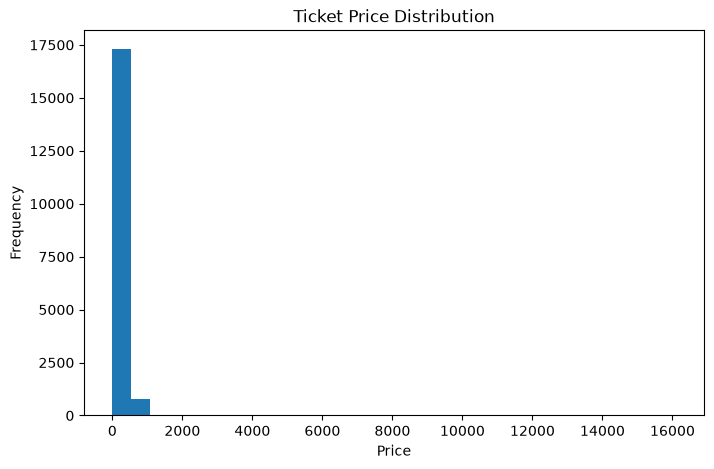

In [178]:
##Fşyat dağılımı
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Ticket Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

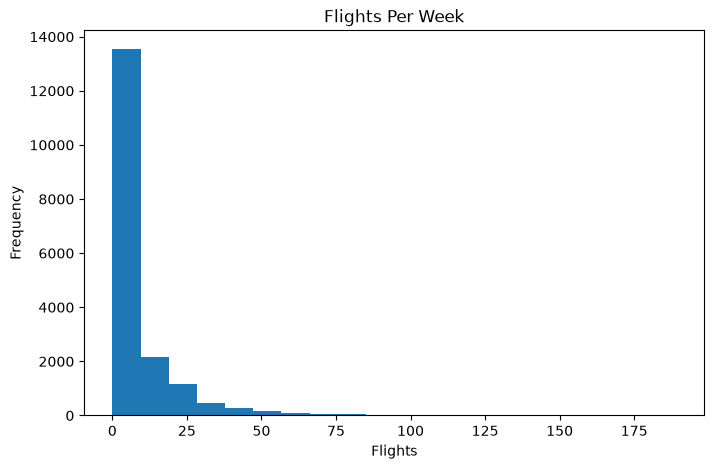

In [179]:
##Haftalık uçuş dağılımı
plt.figure(figsize=(8,5))
plt.hist(df["flights_per_week"], bins=20)
plt.title("Flights Per Week")
plt.xlabel("Flights")
plt.ylabel("Frequency")
plt.show()

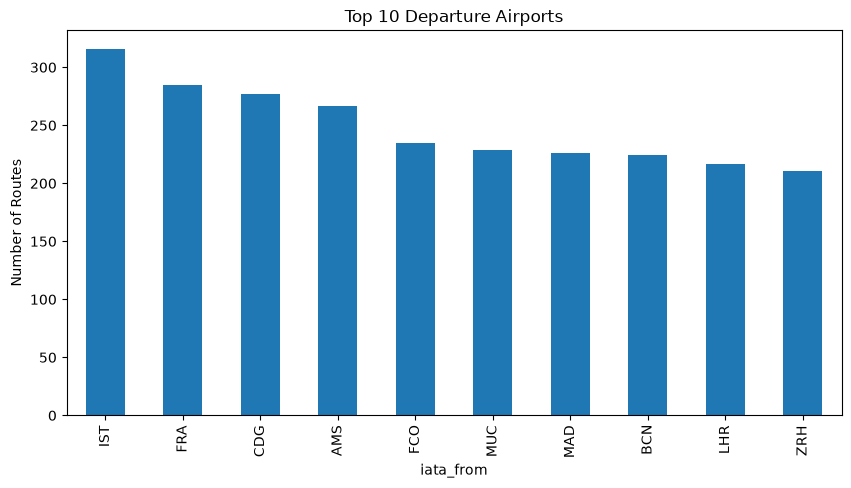

In [180]:
top10 = df["iata_from"].value_counts().head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Departure Airports")

plt.ylabel("Number of Routes")

plt.savefig("top10_departure_airports.png", dpi=300, bbox_inches="tight")

plt.show()



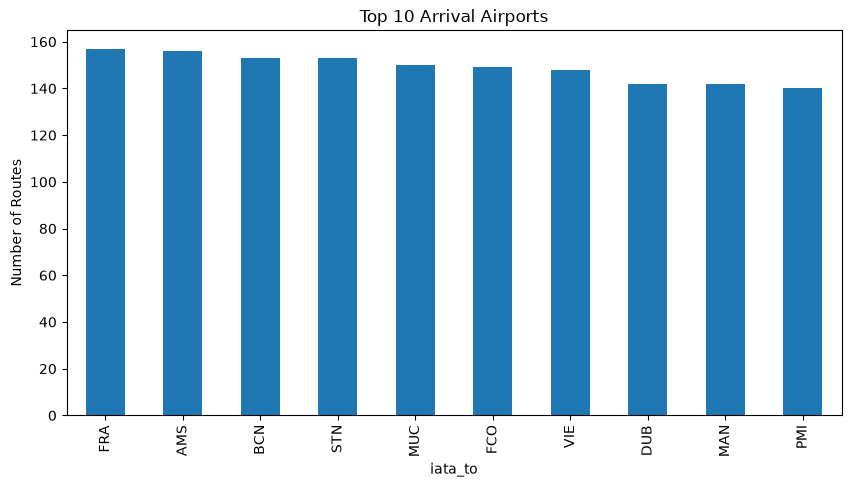

In [181]:
top10 = df["iata_to"].value_counts().head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Arrival Airports")

plt.ylabel("Number of Routes")

plt.show()